In [1]:
import numpy as np
from scipy import signal
from scipy.linalg import inv
import matplotlib.pyplot as plt
import scipy
from scipy.integrate import solve_ivp
import random
import functools
from scipy.optimize import curve_fit


300


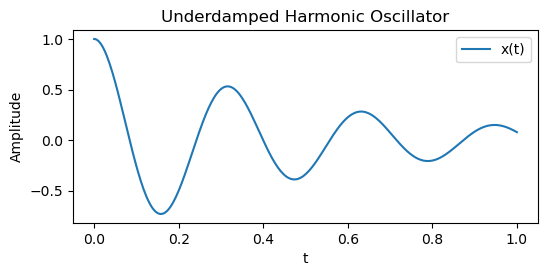

In [2]:
def mass_damper(delta,omega0,t):
    omega = np.sqrt(omega0**2 - delta**2)
    phi = np.arctan(-delta/omega)
    A = 1/(2*np.cos(phi))
    coss = np.cos(phi+omega*t)
    exp = np.exp(-delta*t)
    y = exp*2*A*coss
    return y

# ---------------------------
# sample ground truth
# ---------------------------
dd = 2
w00=20
times = np.linspace(0,1,300)
yexact = mass_damper(dd,w00,times)
print(len(yexact))

# ---------------------------
# plot
# ---------------------------

plt.figure(figsize=(6,2.5))
plt.plot(times, yexact,label="x(t)")
plt.xlabel("t")
plt.ylabel("Amplitude")
plt.title("Underdamped Harmonic Oscillator")
plt.legend()
plt.show()

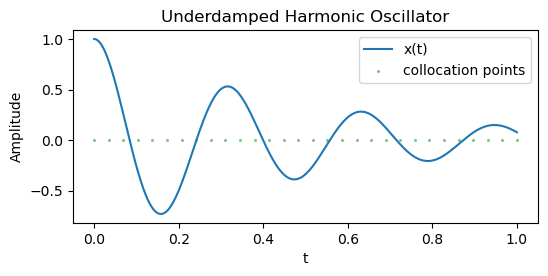

In [3]:
def underdamped(t, y, delta, omega0):
    x, v = y
    dxdt = v
    dvdt = -2*delta*v - omega0**2*x
    return [dxdt, dvdt]

# ---------------------------
# sample ground truth and set parameters values for underdamped solution
# ---------------------------
delta_val = 2
omega0_val = 20


underdamped_fixed = functools.partial(underdamped, delta=delta_val, omega0=omega0_val)

# Solve the ODE
y0 = [1.0, 0.0]                     # initial displacement=1, velocity=0
t_span = (0, 1)                     # simulate from 0 to 1 s
t_eval = np.linspace(*t_span, 300)  # time points for output
t_eval_col = np.linspace(*t_span, 30)  # reshape for compatibility with solve_ivp

sol = solve_ivp(underdamped_fixed,t_span,y0,t_eval=t_eval)
#print(len(sol.y[0]))
times = sol.t
yexact2 = sol.y[0]
#print(type(yexact2))
ydotexact2 = sol.y[1]

y_pred_phys = solve_ivp(underdamped_fixed,t_span,y0,t_eval=t_eval_col)
y_pred_phys2 = y_pred_phys.y[0]
ydot_pred_phys2 = y_pred_phys.y[1]
#print(len(y_pred_phys2))
# ---------------------------
# plot
# ---------------------------
plt.figure(figsize=(6,2.5))

plt.scatter (t_eval_col, np.zeros_like(t_eval_col), s=5, lw=0, color="tab:green", label="collocation points", alpha=0.6)
plt.plot(times, yexact2,label="x(t)")
plt.xlabel("t")
plt.ylabel("Amplitude")
plt.title("Underdamped Harmonic Oscillator")
plt.legend()
plt.show()


do dft to get frequency response function


0.0033444816053511705
xf: [  0.           0.99666667   1.99333333   2.99         3.98666667
   4.98333333   5.98         6.97666667   7.97333333   8.97
   9.96666667  10.96333333  11.96        12.95666667  13.95333333
  14.95        15.94666667  16.94333333  17.94        18.93666667
  19.93333333  20.93        21.92666667  22.92333333  23.92
  24.91666667  25.91333333  26.91        27.90666667  28.90333333
  29.9         30.89666667  31.89333333  32.89        33.88666667
  34.88333333  35.88        36.87666667  37.87333333  38.87
  39.86666667  40.86333333  41.86        42.85666667  43.85333333
  44.85        45.84666667  46.84333333  47.84        48.83666667
  49.83333333  50.83        51.82666667  52.82333333  53.82
  54.81666667  55.81333333  56.81        57.80666667  58.80333333
  59.8         60.79666667  61.79333333  62.79        63.78666667
  64.78333333  65.78        66.77666667  67.77333333  68.77
  69.76666667  70.76333333  71.76        72.75666667  73.75333333
  74.75       

No handles with labels found to put in legend.


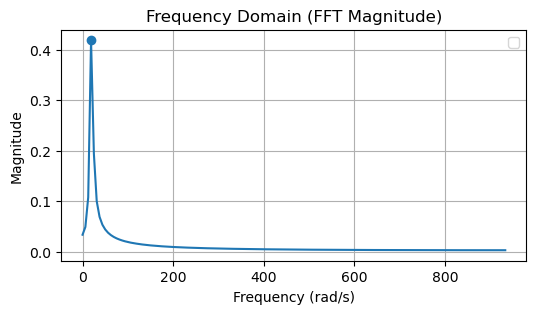

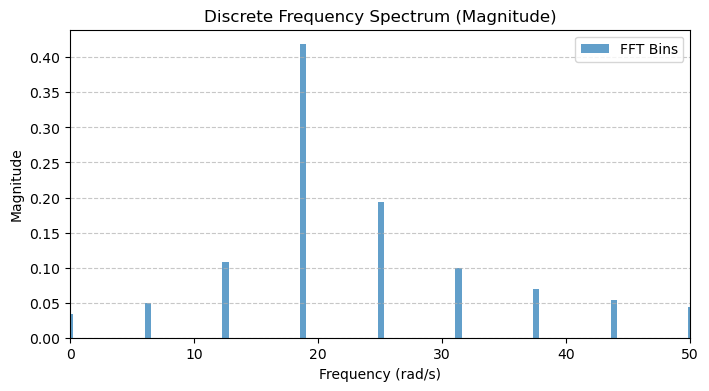

In [4]:
#print(times)
#print(yexact2)

N = len(yexact2)
dt = times[1] - times[0]  # Sampling interval
print(dt)
yf = np.fft.fft(yexact2)
xf = np.fft.fftfreq(N, dt)[:N//2] # Get positive frequencies
print(f"xf: {xf}")

# 2. Get Magnitude (Power Spectrum)
magnitude = 2.0/N * np.abs(yf[0:N//2])

# 2. Get Magnitude (Power Spectrum)
magnitude = 2.0/N * np.abs(yf[0:N//2])

# 3. Find the peak frequency (Experimental wd)
peak_index = np.argmax(magnitude)
print(peak_index)
wd_experimental = xf[peak_index] * 2 * np.pi # Convert Hz to rad/s
print(f"Experimental Damped Frequency (wd): {wd_experimental:.2f} rad/s")

plt.figure(figsize=(6,3))
plt.plot(xf * 2 * np.pi, magnitude)
#plt.axvline(wd_experimental, color='r', linestyle='--', label=f'Peak at {wd_experimental:.2f} rad/s')
plt.scatter(wd_experimental, magnitude[peak_index])
plt.title("Frequency Domain (FFT Magnitude)")
plt.xlabel("Frequency (rad/s)")
plt.ylabel("Magnitude")
plt.legend()
plt.grid(True)
plt.show()



plt.figure(figsize=(8, 4))

# Using bar to show the 'bins'
plt.bar(xf * 2 * np.pi, magnitude, width=0.5, color='tab:blue', alpha=0.7, label='FFT Bins')

# Optional: Add a stem plot on top for clarity
#plt.stem(xf * 2 * np.pi, magnitude, linefmt='r-', markerfmt='ro', basefmt=" ", label='Discrete Frequencies')

plt.title("Discrete Frequency Spectrum (Magnitude)")
plt.xlabel("Frequency (rad/s)")
plt.ylabel("Magnitude")
plt.xlim(0, 50) # Zooming in on the area of interest (near omega0=20)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Get theoretical response magnitude of the system using wn, and zeta

In [5]:

delta_val = 2
omega0_val = 20
wn = omega0_val
zeta = delta_val/wn



def response_magnitude(w, wn, zeta):
    # Fixed initial conditions from your code
    x0, v0 = y0[0], y0[1]



    numerator = np.sqrt((v0 + 2*zeta*wn*x0)**2 + (w*x0)**2)
    denominator = np.sqrt((wn**2 - w**2)**2 + (2*zeta*wn*w)**2)
    return numerator / denominator

Nonlinear least squares regression to find parameters


In [6]:

def response_magnitude(w, wn, zeta):
    # Fixed initial conditions from your code
    x0, v0 = y0[0], y0[1]



    numerator = np.sqrt((v0 + 2*zeta*wn*x0)**2 + (w*x0)**2)
    denominator = np.sqrt((wn**2 - w**2)**2 + (2*zeta*wn*w)**2)
    return numerator / denominator

xf_rad = xf*2*np.pi

mask = (xf_rad > 0) & (xf_rad < 50) # only choosing frequencies between 0 and 50 where the max response magnitude is


w_data = xf_rad[mask]
mag_data = magnitude[mask]
print(w_data)
print(mag_data)


popt, _ = curve_fit(response_magnitude, w_data, mag_data, p0=[15, 0.1]) #p0 is wn and zeta guess

wn_fit, zeta_fit = popt
print(f"Approximated wn: {wn_fit:.2f} rad/s")
print(f"Approximated zeta: {zeta_fit:.4f}")



[ 6.26224136 12.52448271 18.78672407 25.04896542 31.31120678 37.57344814
 43.83568949]
[0.04908346 0.10766767 0.41838709 0.19373419 0.09992488 0.06905612
 0.05354809]
Approximated wn: 19.96 rad/s
Approximated zeta: -0.0000


/Users/abhi/opt/anaconda3/lib/python3.8/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


get parameters m, k, c from our fit

In [7]:
m_est = 1.0
k_est = m_est * (wn_fit**2) #really finding k/m
c_est = 2 * zeta_fit * wn_fit * m_est #really finding c/m

print(f"Calculated Parameters: k={k_est:.2f}, c={c_est:.2f}")

Calculated Parameters: k=398.23, c=-0.00


results make sense since this was an underdamped system